In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import r2_score

# Import your custom supply chain evaluation metrics
from utils import rmse, coeff_determination, smape

print("TensorFlow version:", tf.__version__)
print("All dependencies imported successfully!")

TensorFlow version: 2.21.0
All dependencies imported successfully!


In [2]:
def transformer_encoder(inputs, head_size, num_heads, ff_dim, dropout=0):
    # Normalization and Attention Step
    x = layers.LayerNormalization(epsilon=1e-6)(inputs)
    x = layers.MultiHeadAttention(
        key_dim=head_size, num_heads=num_heads, dropout=dropout
    )(x, x)
    x = layers.Dropout(dropout)(x)
    res = x + inputs

    # Feed Forward Step
    x = layers.LayerNormalization(epsilon=1e-6)(res)
    x = layers.Conv1D(filters=ff_dim, kernel_size=1, activation="relu")(x)
    x = layers.Dropout(dropout)(x)
    x = layers.Conv1D(filters=inputs.shape[-1], kernel_size=1)(x)
    return x + res

In [3]:
def build_transformer_model(input_shape, head_size, num_heads, ff_dim, num_transformer_blocks, mlp_units, dropout=0, mlp_dropout=0):
    inputs = keras.Input(shape=input_shape)
    x = inputs
    
    # Stack multiple transformer blocks
    for _ in range(num_transformer_blocks):
        x = transformer_encoder(x, head_size, num_heads, ff_dim, dropout)

    x = layers.GlobalAveragePooling1D(data_format="channels_first")(x)
    
    # Dense Projection Layers
    for dim in mlp_units:
        x = layers.Dense(dim, activation="relu")(x)
        x = layers.Dropout(mlp_dropout)(x)
        
    # Output Layer: Single value forecasting future unit sales/demand
    outputs = layers.Dense(1)(x)
    
    model = Model(inputs, outputs)
    return model

In [4]:
# 1. Simulate data dimensions: [Samples, Lookback window periods, Features]
X_train = np.random.randn(500, 30, 5).astype(np.float32)
y_train = np.random.randn(500, 1).astype(np.float32)

X_val = np.random.randn(100, 30, 5).astype(np.float32)
y_val = np.random.randn(100, 1).astype(np.float32)

# 2. Define Hyperparameters
input_shape = (X_train.shape[1], X_train.shape[2]) # (30 days lookback, 5 features)

model = build_transformer_model(
    input_shape,
    head_size=64,
    num_heads=4,
    ff_dim=64,
    num_transformer_blocks=2,
    mlp_units=[128, 64],
    dropout=0.1,
    mlp_dropout=0.1
)

# 3. Compile model using your custom metric requirements
model.compile(
    optimizer="adam",
    loss="mse",
    metrics=[rmse, smape, coeff_determination]
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)      │ (None, 30, 5)             │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ layer_normalization           │ (None, 30, 5)             │              10 │ input_layer[0][0]          │
│ (LayerNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ multi_head_attention          │ (None, 30, 5)             │           5,893 │ layer_normalization[0][0], │
│ (MultiHeadAttention)          │                           │                 │ layer_normalization[0][0]  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout_1 (Dropout)           │ (None, 30, 5)             │               0 │ multi_head_attention[0][0] │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ add (Add)                     │ (None, 30, 5)             │               0 │ dropout_1[0][0],           │
│                               │                           │                 │ input_layer[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ layer_normalization_1         │ (None, 30, 5)             │              10 │ add[0][0]                  │
│ (LayerNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1d (Conv1D)               │ (None, 30, 64)            │             384 │ layer_normalization_1[0][… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout_2 (Dropout)           │ (None, 30, 64)            │               0 │ conv1d[0][0]               │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1d_1 (Conv1D)             │ (None, 30, 5)             │             325 │ dropout_2[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ add_1 (Add)                   │ (None, 30, 5)             │               0 │ conv1d_1[0][0], add[0][0]  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ layer_normalization_2         │ (None, 30, 5)             │              10 │ add_1[0][0]                │
│ (LayerNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ multi_head_attention_1        │ (None, 30, 5)             │           5,893 │ layer_normalization_2[0][… │
│ (MultiHeadAttention)          │                           │                 │ layer_normalization_2[0][… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout_4 (Dropout)           │ (None, 30, 5)             │               0 │ multi_head_attention_1[0]… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ add_2 (Add)                   │ (None, 30, 5)             │               0 │ dropout_4[0][0],           │
│                               │                           │               

 Total params: 25,533 (99.74 KB)

 Trainable params: 25,533 (99.74 KB)

 Non-trainable params: 0 (0.00 B)

In [5]:
# 1. Compile the model FIRST with eager execution enabled
model.compile(
    optimizer="adam",
    loss="mse",
    metrics=[rmse, smape, coeff_determination],
    run_eagerly=True  
)

# 2. Set up your training callbacks
callbacks = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
    ModelCheckpoint('Transformer_Demand_Model.h5', monitor='val_loss', save_best_only=True)
]

# 3. Start the actual training loop
print("Starting Transformer Model Training...")
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=10,             
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)
print("Training completed! Best model weights saved to 'Transformer_Demand_Model.h5'")

Starting Transformer Model Training...
Epoch 1/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 639ms/step - coeff_determination: -0.0719 - loss: 1.2834 - rmse: 1.1244 - smape: 165.4329

16/16 ━━━━━━━━━━━━━━━━━━━━ 12s 700ms/step - coeff_determination: -0.0647 - loss: 1.0949 - rmse: 1.0312 - smape: 165.2792 - val_coeff_determination: -0.1480 - val_loss: 0.6267 - val_rmse: 0.7295 - val_smape: 155.8239
Epoch 2/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 12s 755ms/step - coeff_determination: 0.0133 - loss: 1.0090 - rmse: 0.9919 - smape: 157.4902 - val_coeff_determination: -0.1852 - val_loss: 0.6325 - val_rmse: 0.7371 - val_smape: 163.9069
Epoch 3/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 12s 723ms/step - coeff_determination: 0.0763 - loss: 0.9543 - rmse: 0.9680 - smape: 157.5776 - val_coeff_determination: -0.2256 - val_loss: 0.6420 - val_rmse: 0.7461 - val_smape: 160.0091
Epoch 4/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 12s 764ms/step - coeff_determination: 0.0618 - loss: 0.9393 - rmse: 0.9649 - smape: 151.4851 - val_coeff_determination: -0.3275 - val_loss: 0.6606 - val_rmse: 0.7662 - val_smape: 158.4824
Epoch 5/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 11s 670ms/step - coeff_determination: 0.1520 - loss: 0.8709 - rmse: 

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step


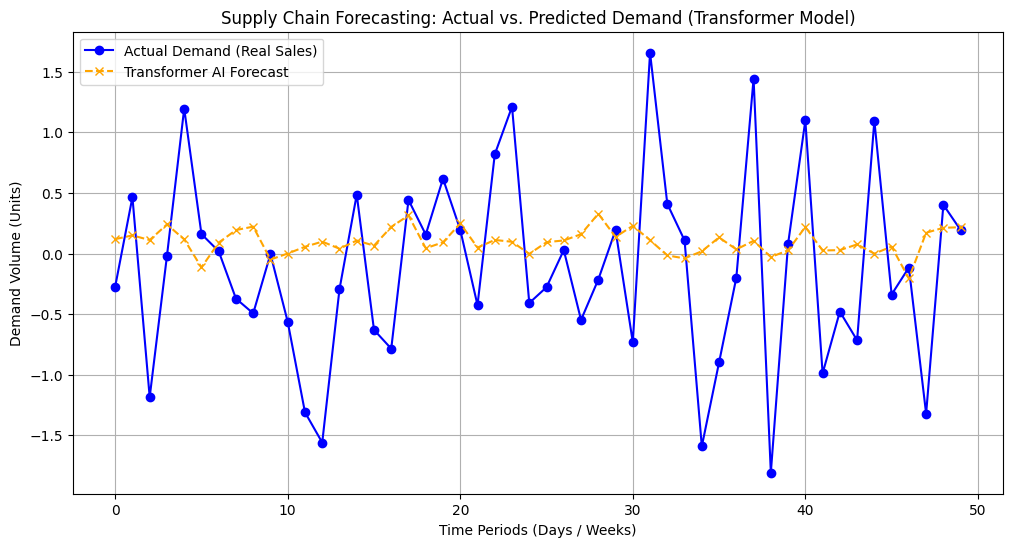

--- Model Evaluation Summary ---
Final Validation RMSE: 0.7916
Final Validation SMAPE: 160.82%


In [6]:
import matplotlib.pyplot as plt

# 1. Use the trained model to predict demand values on your validation data
predictions = model.predict(X_val)

# 2. Set up a clear visualization comparing actual demand vs predicted demand
plt.figure(figsize=(12, 6))
plt.plot(y_val[:50], label='Actual Demand (Real Sales)', color='blue', marker='o')
plt.plot(predictions[:50], label='Transformer AI Forecast', color='orange', linestyle='--', marker='x')

plt.title('Supply Chain Forecasting: Actual vs. Predicted Demand (Transformer Model)')
plt.xlabel('Time Periods (Days / Weeks)')
plt.ylabel('Demand Volume (Units)')
plt.legend()
plt.grid(True)
plt.show()

# 3. Print out final overall business performance metrics
print("--- Model Evaluation Summary ---")
print(f"Final Validation RMSE: {rmse(y_val, predictions):.4f}")
print(f"Final Validation SMAPE: {smape(y_val, predictions):.2f}%")

In [7]:
# View the structural summary directly from the active trained model
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)      │ (None, 30, 5)             │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ layer_normalization           │ (None, 30, 5)             │              10 │ input_layer[0][0]          │
│ (LayerNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ multi_head_attention          │ (None, 30, 5)             │           5,893 │ layer_normalization[0][0], │
│ (MultiHeadAttention)          │                           │                 │ layer_normalization[0][0]  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout_1 (Dropout)           │ (None, 30, 5)             │               0 │ multi_head_attention[0][0] │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ add (Add)                     │ (None, 30, 5)             │               0 │ dropout_1[0][0],           │
│                               │                           │                 │ input_layer[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ layer_normalization_1         │ (None, 30, 5)             │              10 │ add[0][0]                  │
│ (LayerNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1d (Conv1D)               │ (None, 30, 64)            │             384 │ layer_normalization_1[0][… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout_2 (Dropout)           │ (None, 30, 64)            │               0 │ conv1d[0][0]               │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1d_1 (Conv1D)             │ (None, 30, 5)             │             325 │ dropout_2[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ add_1 (Add)                   │ (None, 30, 5)             │               0 │ conv1d_1[0][0], add[0][0]  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ layer_normalization_2         │ (None, 30, 5)             │              10 │ add_1[0][0]                │
│ (LayerNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ multi_head_attention_1        │ (None, 30, 5)             │           5,893 │ layer_normalization_2[0][… │
│ (MultiHeadAttention)          │                           │                 │ layer_normalization_2[0][… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout_4 (Dropout)           │ (None, 30, 5)             │               0 │ multi_head_attention_1[0]… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ add_2 (Add)                   │ (None, 30, 5)             │               0 │ dropout_4[0][0],           │
│                               │                           │               

 Total params: 76,601 (299.23 KB)

 Trainable params: 25,533 (99.74 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 51,068 (199.49 KB)

In [8]:
# Loop through the layers of your active trained model
print("--- Inside the Model: Layer Weights and Biases ---")
for layer in model.layers:
    weights = layer.get_weights()
    if len(weights) > 0:
        print(f"\nLayer Name: {layer.name}")
        print(f"-> Weights shape: {weights[0].shape}")
    else:
        print(f"\nLayer Name: {layer.name} (This layer has no trainable parameters)")

--- Inside the Model: Layer Weights and Biases ---

Layer Name: input_layer (This layer has no trainable parameters)

Layer Name: layer_normalization
-> Weights shape: (5,)

Layer Name: multi_head_attention
-> Weights shape: (5, 4, 64)

Layer Name: dropout_1 (This layer has no trainable parameters)

Layer Name: layer_normalization_1
-> Weights shape: (5,)

Layer Name: conv1d
-> Weights shape: (1, 5, 64)

Layer Name: dropout_2 (This layer has no trainable parameters)

Layer Name: conv1d_1
-> Weights shape: (1, 64, 5)

Layer Name: layer_normalization_2
-> Weights shape: (5,)

Layer Name: multi_head_attention_1
-> Weights shape: (5, 4, 64)

Layer Name: dropout_4 (This layer has no trainable parameters)

Layer Name: layer_normalization_3
-> Weights shape: (5,)

Layer Name: conv1d_2
-> Weights shape: (1, 5, 64)

Layer Name: dropout_5 (This layer has no trainable parameters)

Layer Name: conv1d_3
-> Weights shape: (1, 64, 5)

Layer Name: global_average_pooling1d (This layer has no trainable 